In [2]:
import matplotlib.pyplot as plt
from collections import Counter
from src.data import load_dataset

# Point Benchmarks

## Point TempEval

In [3]:
trainset = load_dataset("point_tempeval", "train")
validset = load_dataset("point_tempeval", "valid")
testset = load_dataset("point_tempeval", "test")

100%|██████████| 275/275 [00:00<00:00, 591.99it/s]


In [4]:
train_labels = trainset["label"]
train_labels_counter = Counter(train_labels)

valid_labels = validset["label"]
valid_labels_counter = Counter(valid_labels)

test_labels = testset["label"]
test_labels_counter = Counter(test_labels)

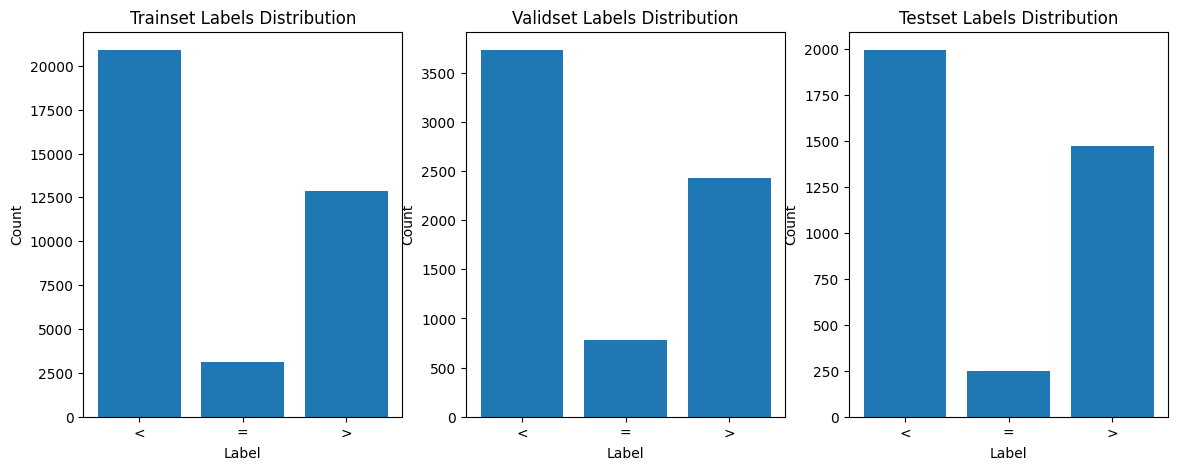

In [5]:
label_order = sorted(train_labels_counter.keys())

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
axs[0].bar(label_order, [train_labels_counter[label] for label in label_order])
axs[0].set_title("Trainset Labels Distribution")
axs[0].set_xlabel("Label")
axs[0].set_ylabel("Count")

axs[1].bar(label_order, [valid_labels_counter[label] for label in label_order])
axs[1].set_title("Validset Labels Distribution")
axs[1].set_xlabel("Label")
axs[1].set_ylabel("Count")

axs[2].bar(label_order, [test_labels_counter[label] for label in label_order])
axs[2].set_title("Testset Labels Distribution")
axs[2].set_xlabel("Label")
axs[2].set_ylabel("Count")
plt.show()

### Per Relation type

In [6]:
def add_text_type(example: dict):
    if "<start_source>" in example["text"] and "<start_target>" in example["text"]:
        example["type"] = "ss"  # start-start
    elif "<end_source>" in example["text"] and "<end_target>" in example["text"]:
        example["type"] = "ee"  # end-end
    elif "<start_source>" in example["text"] and "<end_target>" in example["text"]:
        example["type"] = "se"  # start-end
    elif "<end_source>" in example["text"] and "<start_target>" in example["text"]:
        example["type"] = "es"  # end-start
    else:
        raise ValueError(
            f"Text does not contain a valid entity pair: {example['text']}"
        )
    return example

In [7]:
trainset = trainset.map(add_text_type)

Map: 100%|██████████| 36868/36868 [00:01<00:00, 29844.41 examples/s]


In [ ]:
# A table where the rows are the labels and the columns are the types



## Point TempEval Closure

In [20]:
trainset = load_dataset("point_tempeval", "train", closure=True)
validset = load_dataset("point_tempeval", "valid", closure=True)
testset = load_dataset("point_tempeval", "test", closure=True)

100%|██████████| 275/275 [00:00<00:00, 584.88it/s]


In [21]:
train_labels = trainset["label"]
train_labels_counter = Counter(train_labels)

valid_labels = validset["label"]
valid_labels_counter = Counter(valid_labels)

test_labels = testset["label"]
test_labels_counter = Counter(test_labels)

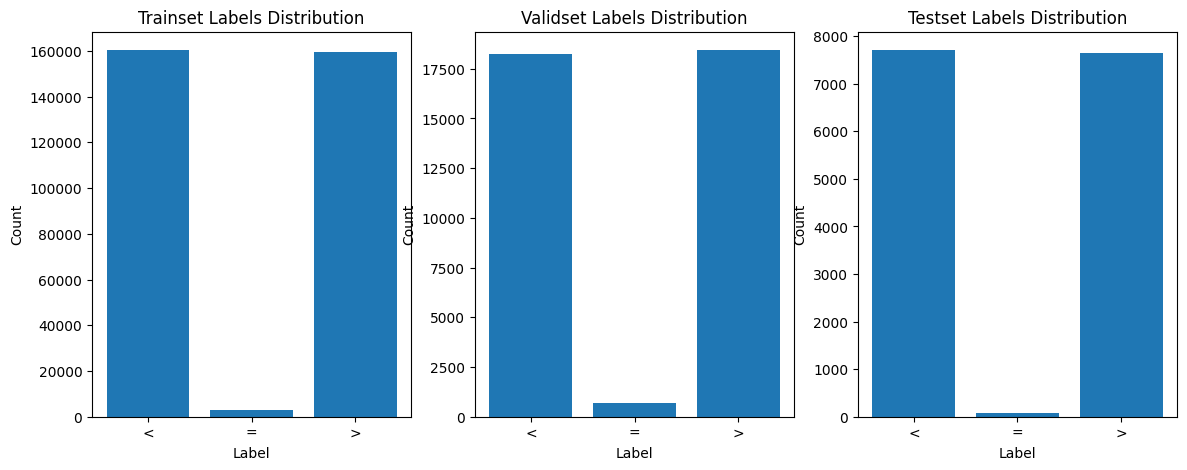

In [22]:
label_order = sorted(train_labels_counter.keys())

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
axs[0].bar(label_order, [train_labels_counter[label] for label in label_order])
axs[0].set_title("Trainset Labels Distribution")
axs[0].set_xlabel("Label")
axs[0].set_ylabel("Count")

axs[1].bar(label_order, [valid_labels_counter[label] for label in label_order])
axs[1].set_title("Validset Labels Distribution")
axs[1].set_xlabel("Label")
axs[1].set_ylabel("Count")

axs[2].bar(label_order, [test_labels_counter[label] for label in label_order])
axs[2].set_title("Testset Labels Distribution")
axs[2].set_xlabel("Label")
axs[2].set_ylabel("Count")
plt.show()

# Interval Benchmarks

## TempEval-3

In [3]:
trainset = load_dataset("interval_tempeval", "train")
validset = load_dataset("interval_tempeval", "valid")
testset = load_dataset("interval_tempeval", "test")

100%|██████████| 275/275 [00:00<00:00, 458.43it/s]


In [4]:
train_labels = trainset["label"]
train_labels_counter = Counter(train_labels)

valid_labels = validset["label"]
valid_labels_counter = Counter(valid_labels)

test_labels = testset["label"]
test_labels_counter = Counter(test_labels)

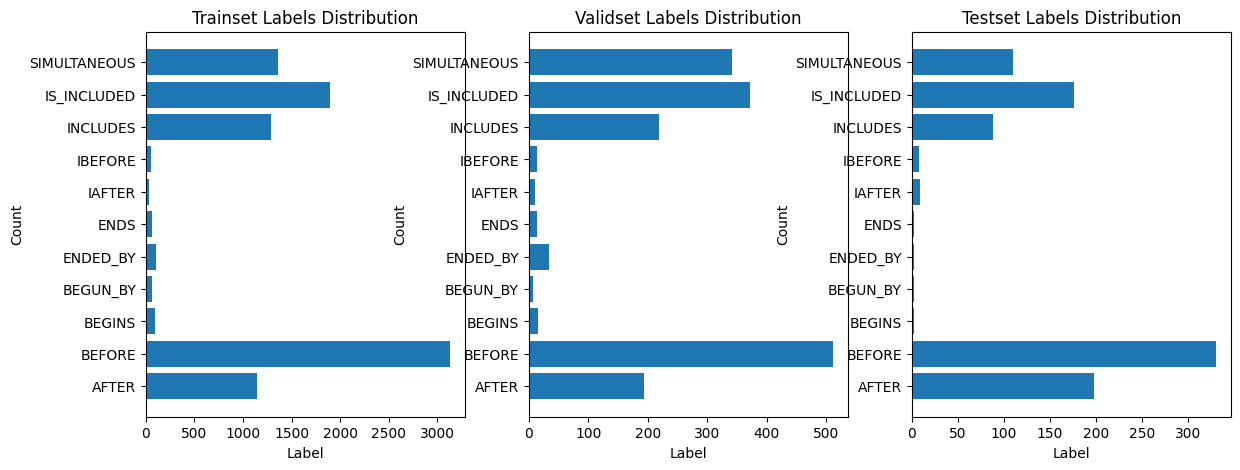

In [5]:
label_order = sorted(train_labels_counter.keys())

fig, axs = plt.subplots(1, 3, figsize=(14, 5))

axs[0].barh(label_order, [train_labels_counter[label] for label in label_order])
axs[0].set_title("Trainset Labels Distribution")
axs[0].set_xlabel("Label")
axs[0].set_ylabel("Count")

axs[1].barh(label_order, [valid_labels_counter[label] for label in label_order])
axs[1].set_title("Validset Labels Distribution")
axs[1].set_xlabel("Label")
axs[1].set_ylabel("Count")

axs[2].barh(label_order, [test_labels_counter[label] for label in label_order])
axs[2].set_title("Testset Labels Distribution")
axs[2].set_xlabel("Label")
axs[2].set_ylabel("Count")
plt.show()

In [6]:
type_count = Counter(testset["type"])
print(type_count.most_common())

[('e-e', 584), ('dct-e', 165), ('e-t', 150), ('dct-t', 23), ('t-t', 7)]


In [8]:
ee_dataset = testset.filter(lambda x: x["type"] == "e-e")
et_dataset = testset.filter(lambda x: x["type"] != "e-e")

Filter: 100%|██████████| 929/929 [00:00<00:00, 180611.31 examples/s]


In [9]:
print(f"Number of e-e examples: {len(ee_dataset)}")
print(f"Number of non e-e examples: {len(et_dataset)}")

Number of e-e examples: 584
Number of non e-e examples: 345


In [23]:
import numpy as np

# make a table where the rows are the labels and the columns are the types
unique_types = ["e-e", "dct-e", "e-t", "dct-t", "t-t"]
unique_labels = [
    "BEFORE",
    "IS_INCLUDED",
    "SIMULTANEOUS",
    "INCLUDES",
    "AFTER",
    "ENDED_BY",
    "BEGINS",
    "ENDS",
    "BEGUN_BY",
    "IBEFORE",
    "IAFTER",
]

table = np.zeros((len(unique_labels), len(unique_types)))

for i, unique_type in enumerate(unique_types):
    for j, unique_label in enumerate(unique_labels):
        dataset = testset.filter(
            lambda x: x["type"] == unique_type and x["label"] == unique_label
        )
        table[j, i] = len(dataset)
print(table)

Filter: 100%|██████████| 929/929 [00:00<00:00, 189823.57 examples/s]

[[227.  90.   6.   6.   1.]
 [ 47.  14. 111.   3.   1.]
 [ 98.   0.   8.   4.   0.]
 [ 40.  36.   4.   6.   2.]
 [167.  25.   4.   2.   0.]
 [  0.   0.   2.   0.   0.]
 [  0.   0.   1.   1.   0.]
 [  1.   0.   2.   0.   0.]
 [  1.   0.   1.   0.   1.]
 [  1.   0.   5.   1.   1.]
 [  2.   0.   6.   0.   1.]]


In [26]:
table.sum()

np.float64(929.0)

In [14]:
table

array([[  2.,   0.,   0.,   0.,   0.],
       [  6.,   0.,   0.,   0.,   0.],
       [111.,   0.,   0.,   0.,   0.],
       [  8.,   0.,   0.,   0.,   0.],
       [  6.,   0.,   0.,   0.,   0.],
       [  5.,   0.,   0.,   0.,   0.],
       [  2.,   0.,   0.,   0.,   0.],
       [  1.,   0.,   0.,   0.,   0.],
       [  1.,   0.,   0.,   0.,   0.],
       [  4.,   0.,   0.,   0.,   0.],
       [  4.,   0.,   0.,   0.,   0.]])

## TempEval-3 Closure

In [10]:
trainset = load_dataset("interval_tempeval", "train", closure=True)
validset = load_dataset("interval_tempeval", "valid", closure=True)
testset = load_dataset("interval_tempeval", "test", closure=True)

100%|██████████| 275/275 [00:00<00:00, 581.95it/s]


In [11]:
train_labels = trainset["label"]
train_labels_counter = Counter(train_labels)

valid_labels = validset["label"]
valid_labels_counter = Counter(valid_labels)

test_labels = testset["label"]
test_labels_counter = Counter(test_labels)

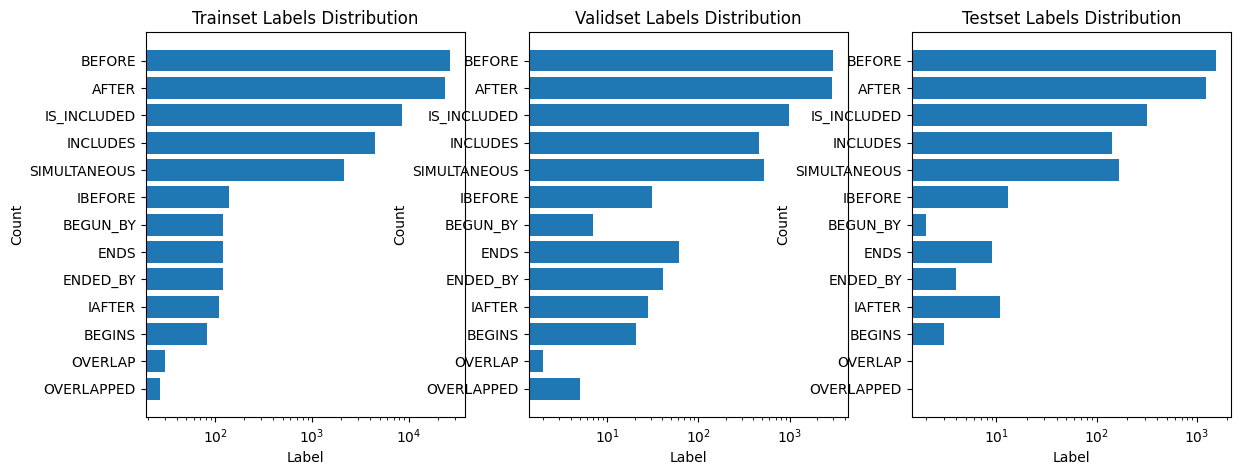

In [12]:
label_order = sorted(train_labels_counter.keys(), key=lambda x: train_labels_counter[x])

fig, axs = plt.subplots(1, 3, figsize=(14, 5))

axs[0].barh(label_order, [train_labels_counter[label] for label in label_order])
axs[0].set_title("Trainset Labels Distribution")
axs[0].set_xlabel("Label")
axs[0].set_ylabel("Count")
axs[0].set_xscale("log")

axs[1].barh(label_order, [valid_labels_counter[label] for label in label_order])
axs[1].set_title("Validset Labels Distribution")
axs[1].set_xlabel("Label")
axs[1].set_ylabel("Count")
axs[1].set_xscale("log")

axs[2].barh(label_order, [test_labels_counter[label] for label in label_order])
axs[2].set_title("Testset Labels Distribution")
axs[2].set_xlabel("Label")
axs[2].set_ylabel("Count")
axs[2].set_xscale("log")

plt.show()

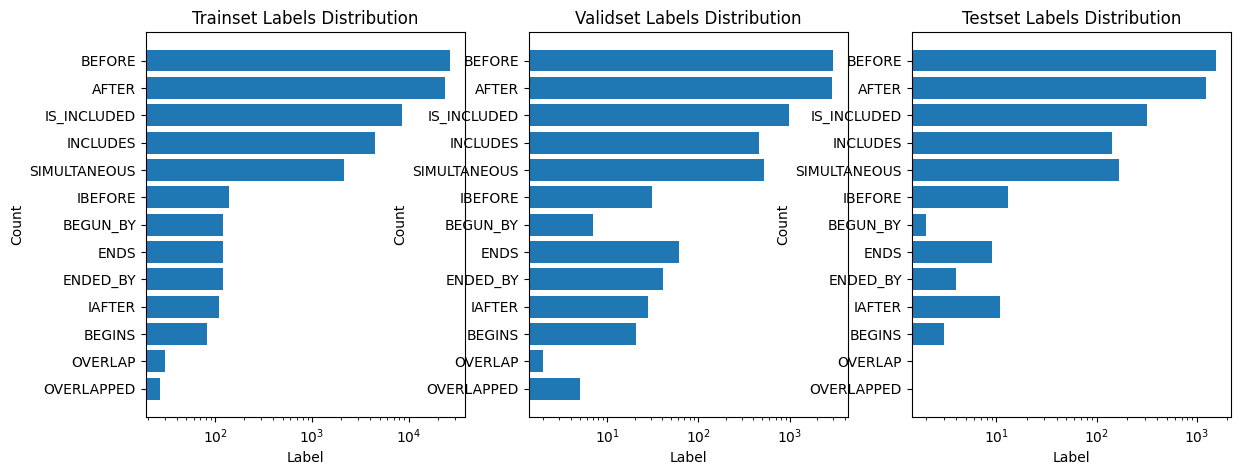

In [9]:
label_order = sorted(train_labels_counter.keys(), key=lambda x: train_labels_counter[x])

fig, axs = plt.subplots(1, 3, figsize=(14, 5))

axs[0].barh(label_order, [train_labels_counter[label] for label in label_order])
axs[0].set_title("Trainset Labels Distribution")
axs[0].set_xlabel("Label")
axs[0].set_ylabel("Count")
axs[0].set_xscale("log")

axs[1].barh(label_order, [valid_labels_counter[label] for label in label_order])
axs[1].set_title("Validset Labels Distribution")
axs[1].set_xlabel("Label")
axs[1].set_ylabel("Count")
axs[1].set_xscale("log")

axs[2].barh(label_order, [test_labels_counter[label] for label in label_order])
axs[2].set_title("Testset Labels Distribution")
axs[2].set_xlabel("Label")
axs[2].set_ylabel("Count")
axs[2].set_xscale("log")

plt.show()

## TDDiscourse

In [3]:
trainset = load_dataset("interval_tddiscourse", "train")
validset = load_dataset("interval_tddiscourse", "valid")
testset = load_dataset("interval_tddiscourse", "test")

100%|██████████| 183/183 [00:00<00:00, 675.67it/s]


In [4]:
train_labels = trainset["label"]
train_labels_counter = Counter(train_labels)

valid_labels = validset["label"]
valid_labels_counter = Counter(valid_labels)

test_labels = testset["label"]
test_labels_counter = Counter(test_labels)

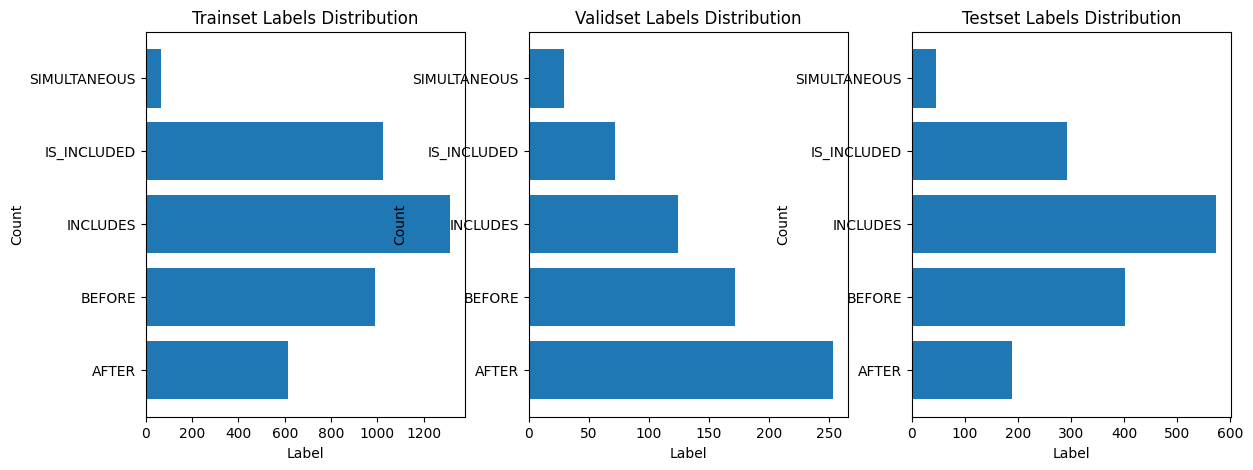

In [6]:
label_order = sorted(train_labels_counter.keys())

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
axs[0].barh(label_order, [train_labels_counter[label] for label in label_order])
axs[0].set_title("Trainset Labels Distribution")
axs[0].set_xlabel("Label")
axs[0].set_ylabel("Count")

axs[1].barh(label_order, [valid_labels_counter[label] for label in label_order])
axs[1].set_title("Validset Labels Distribution")
axs[1].set_xlabel("Label")
axs[1].set_ylabel("Count")

axs[2].barh(label_order, [test_labels_counter[label] for label in label_order])
axs[2].set_title("Testset Labels Distribution")
axs[2].set_xlabel("Label")
axs[2].set_ylabel("Count")
plt.show()

## MeanTime

In [1]:
trainset = load_dataset("interval_meantime", "train")
validset = load_dataset("interval_meantime", "valid")
testset = load_dataset("interval_meantime", "test")

NameError: name 'load_dataset' is not defined

In [10]:
train_labels = trainset["label"]
train_labels_counter = Counter(train_labels)

valid_labels = validset["label"]
valid_labels_counter = Counter(valid_labels)

test_labels = testset["label"]
test_labels_counter = Counter(test_labels)

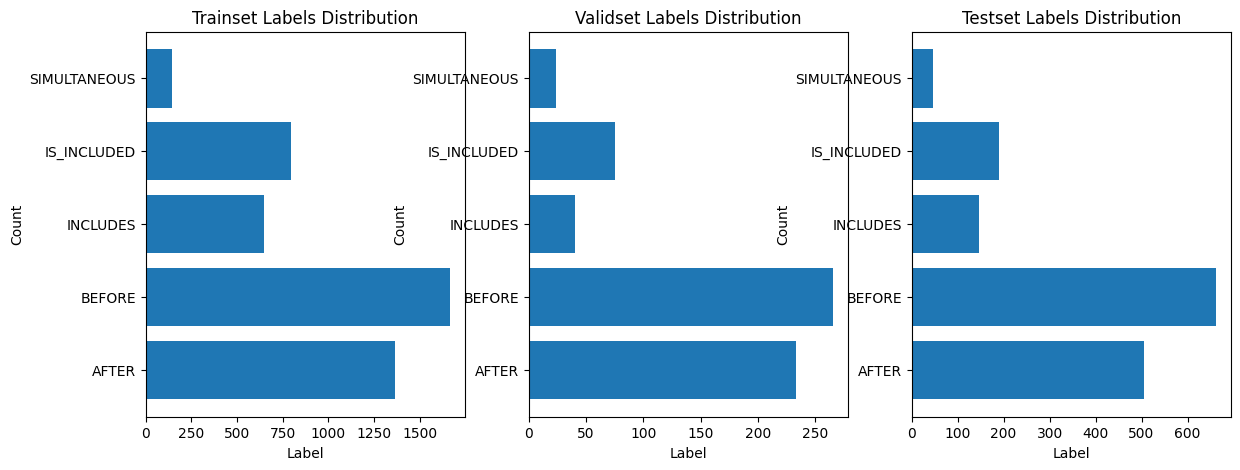

In [12]:
label_order = sorted(train_labels_counter.keys())

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
axs[0].barh(label_order, [train_labels_counter[label] for label in label_order])
axs[0].set_title("Trainset Labels Distribution")
axs[0].set_xlabel("Label")
axs[0].set_ylabel("Count")

axs[1].barh(label_order, [valid_labels_counter[label] for label in label_order])
axs[1].set_title("Validset Labels Distribution")
axs[1].set_xlabel("Label")
axs[1].set_ylabel("Count")

axs[2].barh(label_order, [test_labels_counter[label] for label in label_order])
axs[2].set_title("Testset Labels Distribution")
axs[2].set_xlabel("Label")
axs[2].set_ylabel("Count")
plt.show()

## TimeBankDense

In [3]:
trainset = load_dataset("interval_timebank_dense", "train")
validset = load_dataset("interval_timebank_dense", "valid")
testset = load_dataset("interval_timebank_dense", "test")

100%|██████████| 183/183 [00:00<00:00, 642.88it/s]


data/timebank_dense/train/TimebankDense.full.txt


100%|██████████| 183/183 [00:00<00:00, 672.08it/s]


data/timebank_dense/train/TimebankDense.full.txt


100%|██████████| 183/183 [00:00<00:00, 670.67it/s]


data/timebank_dense/train/TimebankDense.full.txt


In [4]:
train_labels = trainset["label"]
train_labels_counter = Counter(train_labels)

valid_labels = validset["label"]
valid_labels_counter = Counter(valid_labels)

test_labels = testset["label"]
test_labels_counter = Counter(test_labels)

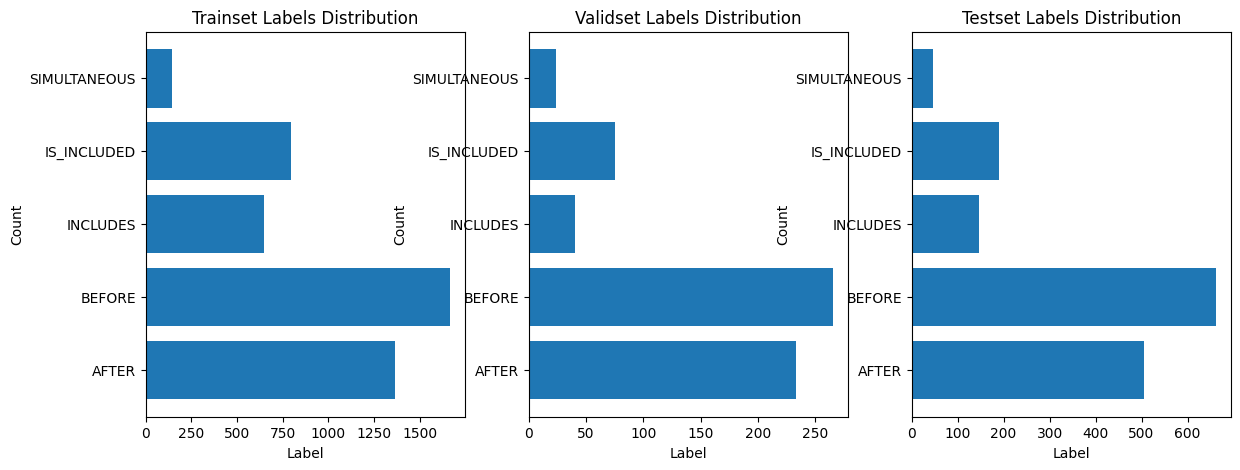

In [5]:
label_order = sorted(train_labels_counter.keys())

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
axs[0].barh(label_order, [train_labels_counter[label] for label in label_order])
axs[0].set_title("Trainset Labels Distribution")
axs[0].set_xlabel("Label")
axs[0].set_ylabel("Count")

axs[1].barh(label_order, [valid_labels_counter[label] for label in label_order])
axs[1].set_title("Validset Labels Distribution")
axs[1].set_xlabel("Label")
axs[1].set_ylabel("Count")

axs[2].barh(label_order, [test_labels_counter[label] for label in label_order])
axs[2].set_title("Testset Labels Distribution")
axs[2].set_xlabel("Label")
axs[2].set_ylabel("Count")
plt.show()